Fitting Growing Neural Gas Network for mnist_one_00000.png...


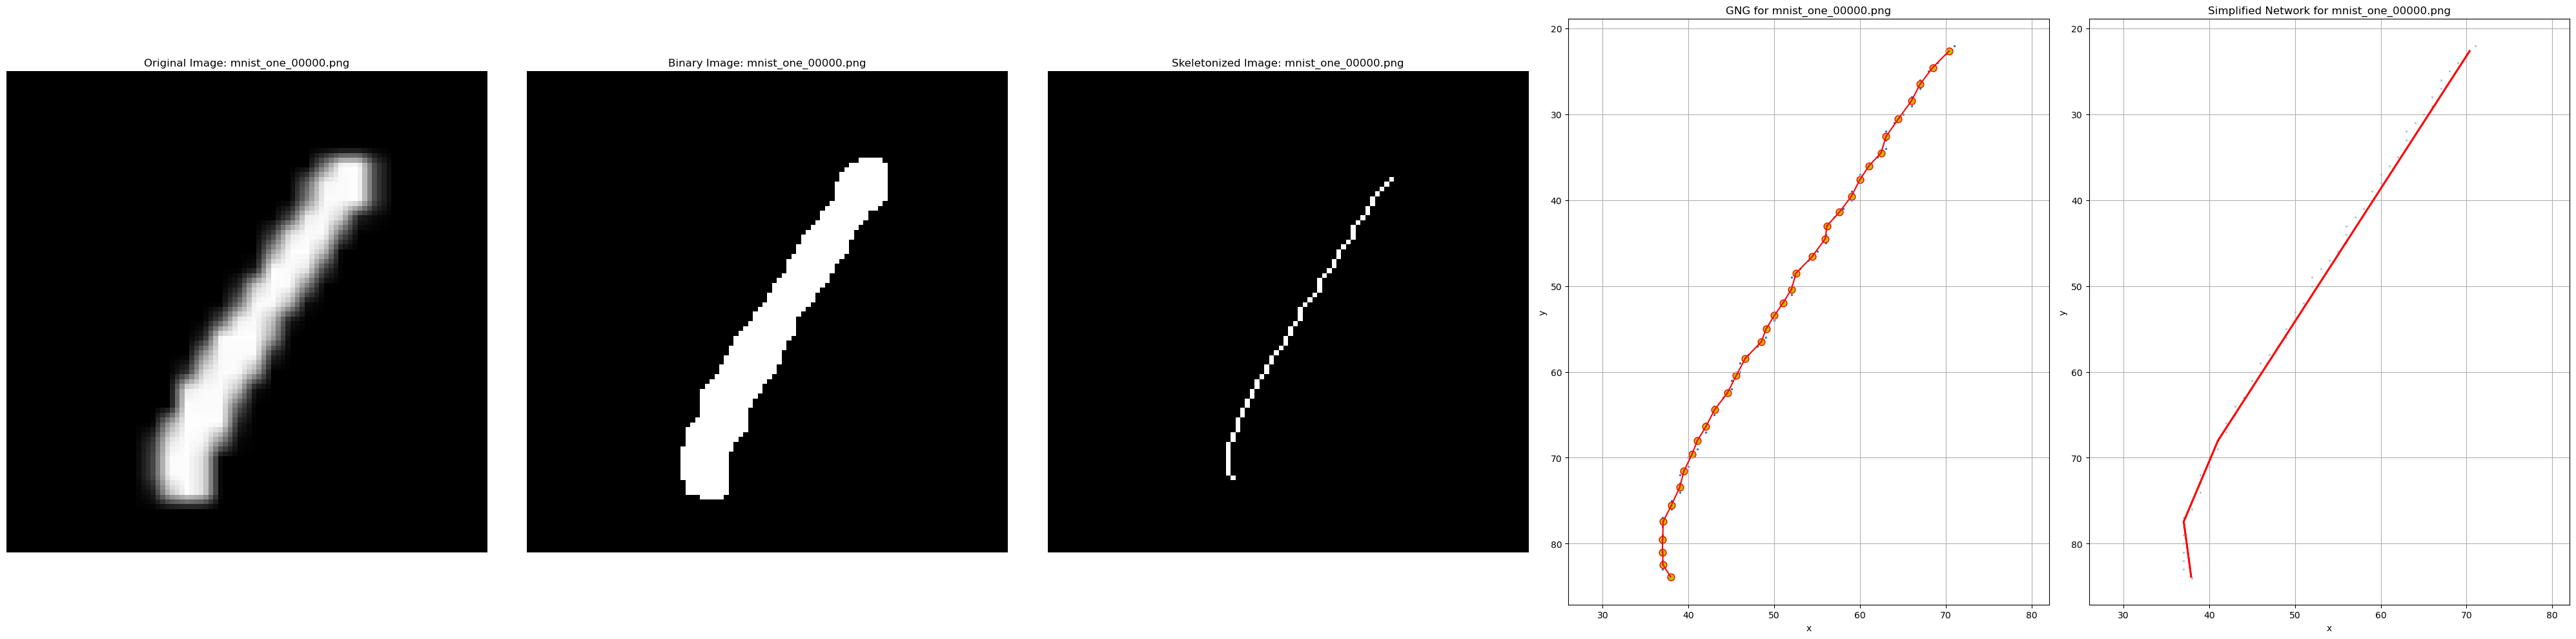

Fitting Growing Neural Gas Network for mnist_four_00003.png...


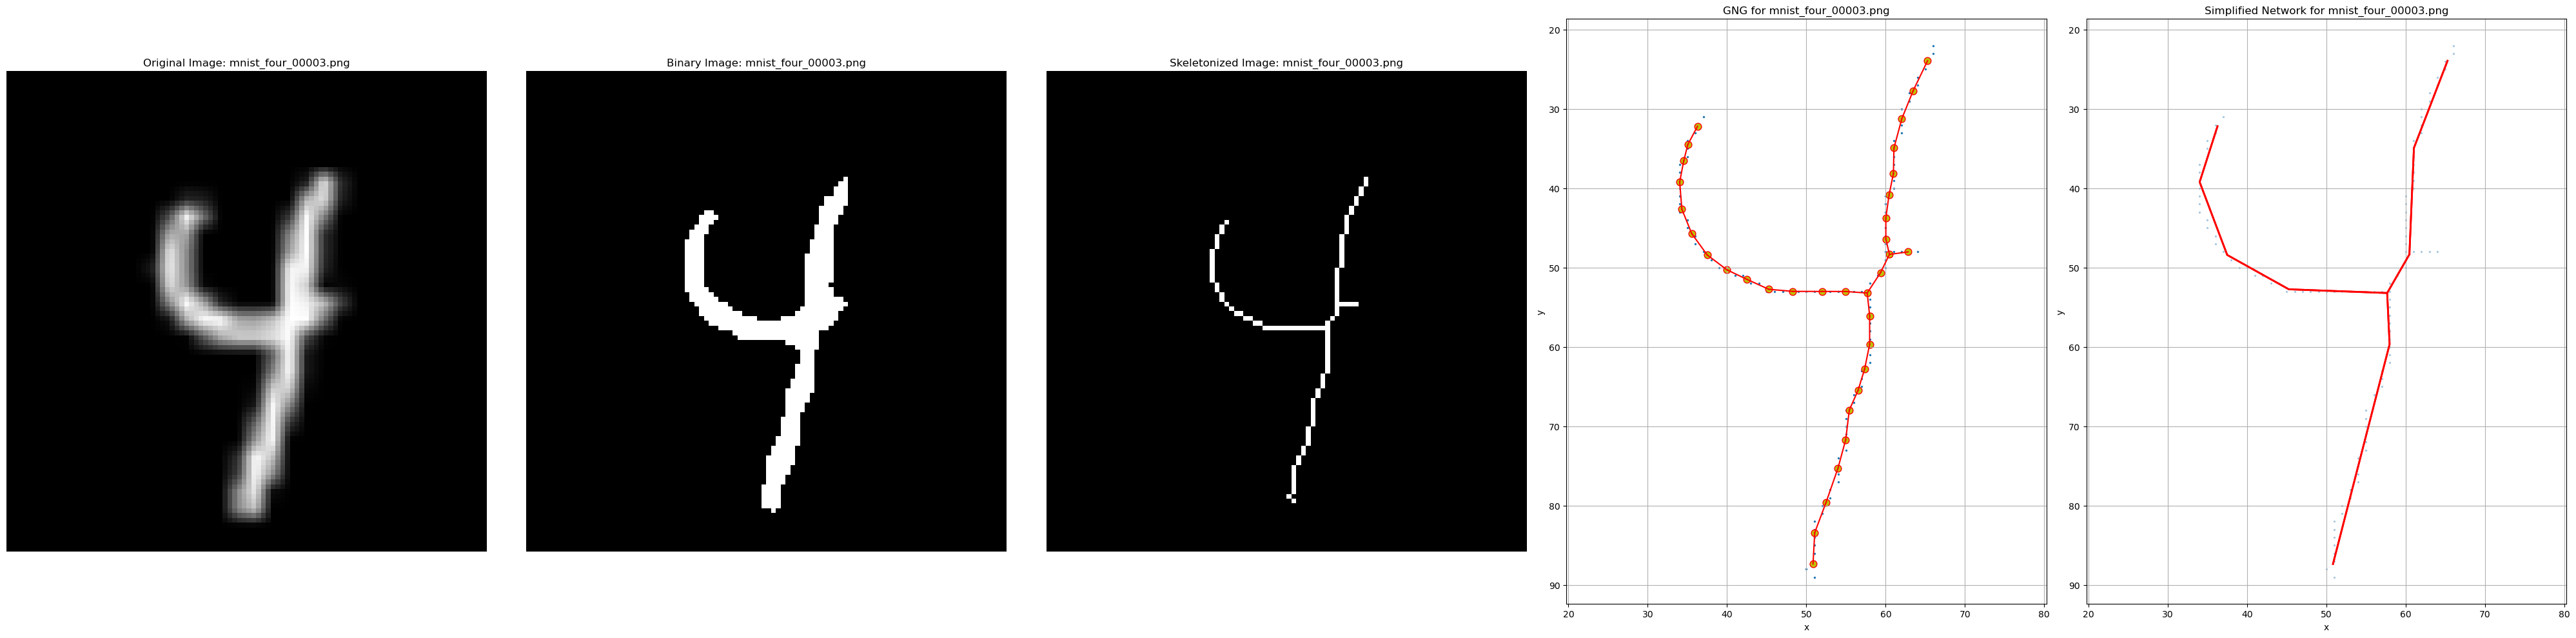

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from ypstruct import structure
import gng
import cv2
import os
from skimage.morphology import skeletonize
from skimage.util import img_as_ubyte
from rdp import rdp
from graph_serializer import GraphSerializer

def simplify_network(net, epsilon=2.0):
    # Find endpoints and intersections
    degree = np.sum(net.C, axis=0)
    endpoints = set(np.where(degree == 1)[0])
    intersections = set(np.where(degree > 2)[0])
    
    simplified_segments = []
    visited_edges = set()
    
    def traverse_segment(start, current):
        segment = [net.w[start]]
        while current not in endpoints and current not in intersections:
            segment.append(net.w[current])
            neighbors = set(np.where(net.C[current] == 1)[0]) - {start}
            if not neighbors:
                break
            start, current = current, neighbors.pop()
        segment.append(net.w[current])
        return segment, current

    def process_node(node):
        neighbors = set(np.where(net.C[node] == 1)[0])
        for neighbor in neighbors:
            if (node, neighbor) not in visited_edges and (neighbor, node) not in visited_edges:
                visited_edges.add((node, neighbor))
                visited_edges.add((neighbor, node))
                segment, end = traverse_segment(node, neighbor)
                if len(segment) > 2:
                    simplified_segment = rdp(np.array(segment), epsilon)
                    simplified_segments.append(simplified_segment)
                if end != neighbor:
                    process_node(end)

    # Process all endpoints and intersections
    for node in endpoints.union(intersections):
        process_node(node)
    
    return simplified_segments

# Read all images from the specified folder
folder_path = '../../tests/generated_samples/sk-test'  # Replace with the actual folder path
image_files = [f for f in os.listdir(folder_path) if f.endswith('.png')]

for image_file in image_files:
    # Read the image
    data = cv2.imread(os.path.join(folder_path, image_file), 0)

    # Skeletonize the image
    binary = data > 160
    skeleton = skeletonize(binary)
    skeleton = img_as_ubyte(skeleton)

    h, w = skeleton.shape

    points = []

    for y in range(h):
        for x in range(w):
            # Threshold the pixel
            if skeleton[y, x] > 0:
                points.append([x, y])

    points_np = np.array(points)


    # Neural Gas Parameters
    params = structure()
    params.N = 35
    params.maxit = 150
    params.L = 100
    params.epsilon_b = 0.2
    params.epsilon_n = 0.01
    params.alpha = 0.5
    params.delta = 0.995
    params.T = 50

    # Fit Neural Gas to Data
    print(f"Fitting Growing Neural Gas Network for {image_file}...")
    net = gng.fit(points_np, params)
    
    # Simplify the network
    simplified_network = simplify_network(net, epsilon=1.0)

    # Create a figure with four subplots side by side
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(40, 10))

    # Plot original image on the left
    ax1.imshow(data, cmap='gray')
    ax1.set_title(f'Original Image: {image_file}')
    ax1.axis('off')
    
    ax2.imshow(binary, cmap='gray')
    ax2.set_title(f'Binary Image: {image_file}')
    ax2.axis('off')

    # Plot skeletonized image in the middle-left
    ax3.imshow(skeleton, cmap='gray')
    ax3.set_title(f'Skeletonized Image: {image_file}')
    ax3.axis('off')

    # Plot GNG result in the middle-right
    ax4.grid()
    ax4.scatter(points_np[:, 0], points_np[:, 1], s=2)
    for i in range(params.N):
        for j in range(i+1, params.N):
            if net.C[i, j] == 1:
                ax4.plot([net.w[i, 0], net.w[j, 0]], [net.w[i, 1], net.w[j, 1]], c='r')

    ax4.scatter(net.w[:, 0], net.w[:, 1], s=60, c='y', edgecolors='r')

    ax4.set_title(f'GNG for {image_file}')
    ax4.set_xlabel('x')
    ax4.set_ylabel('y')
    ax4.axis('equal')
    ax4.invert_yaxis()  # Invert y-axis to match image coordinates

    # Plot simplified network on the right
    ax5.grid()
    ax5.scatter(points_np[:, 0], points_np[:, 1], s=2, alpha=0.3)
    for segment in simplified_network:
        ax5.plot(segment[:, 0], segment[:, 1], 'r-', linewidth=2)

    ax5.set_title(f'Simplified Network for {image_file}')
    ax5.set_xlabel('x')
    ax5.set_ylabel('y')
    ax5.axis('equal')
    ax5.invert_yaxis()  # Invert y-axis to match image coordinates

    plt.tight_layout()
    plt.show()

57.78225907670064
45.21558580899029
37.61684525303038
34.040751622434485
34.05070829953121
36.27486325148093
60.316651813578716
61.53532182930378
65.96153846153842
57.9310303302671
50.74818221525655
53.14583168296444
52.73185025054654
48.56924185737801
42.34747748306088
37.56645258289841
32.056897914788586
47.55493824024834
33.55710070567009
22.523351648351646
60.23856068116915
87.82134483954675


KeyboardInterrupt: 

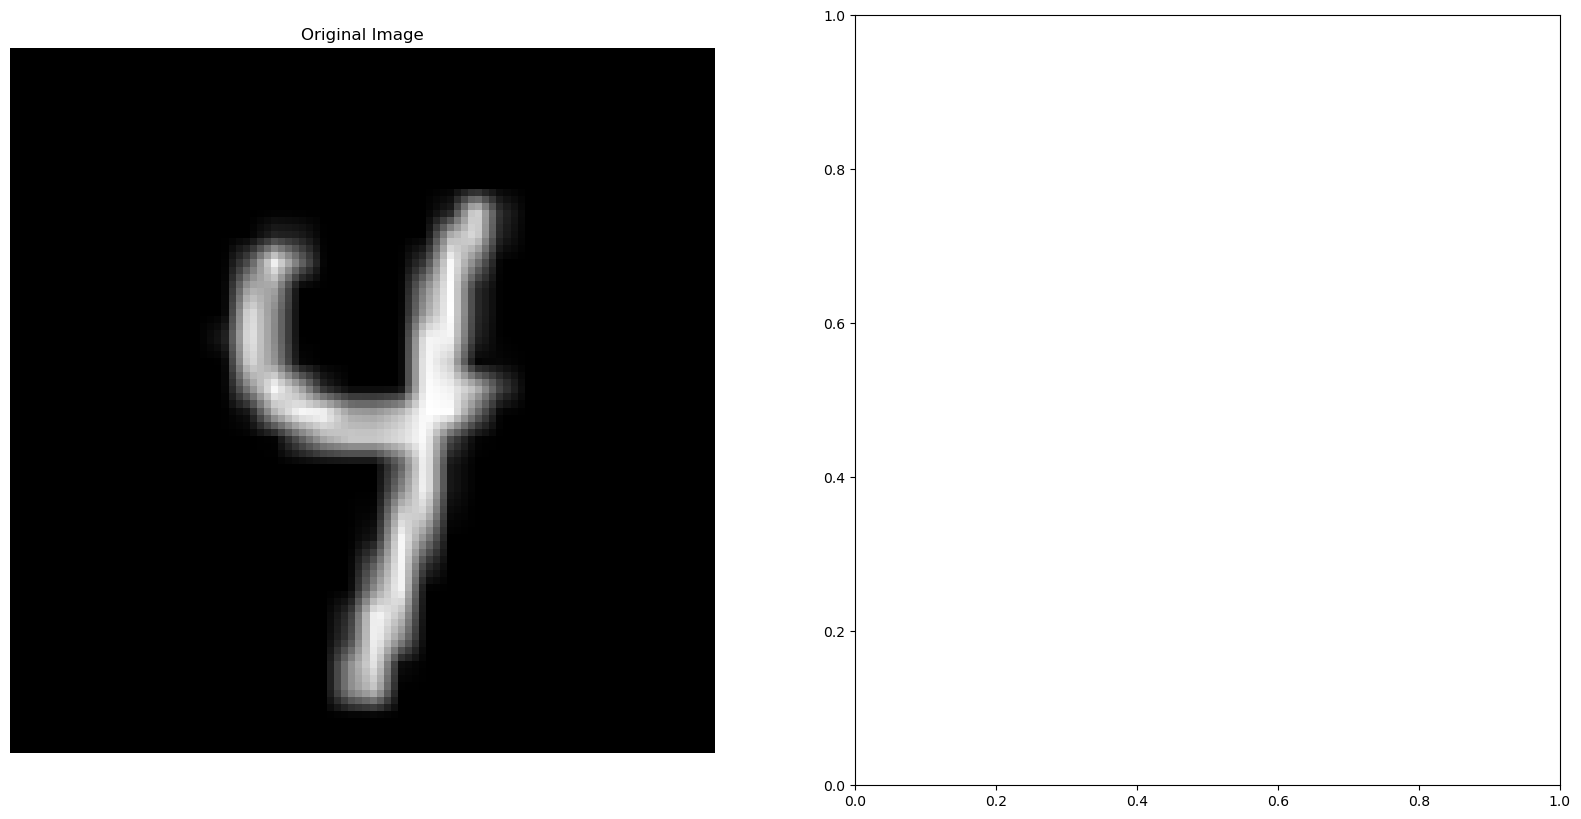

In [63]:
from skeleton_gng_mapper import SkeletonGNGMapper
import networkx as nx
from settings import Settings
import matplotlib.pyplot as plt
import cv2

# path = '../../tests/generated_samples/sk-test/mnist_one_00000.png'
path = '../../tests/generated_samples/sk-test/mnist_four_00003.png'
image = cv2.imread(path, 0)
settings = Settings(
    kafka_topic='skeletonization',
    dlq_topic='skeletonization-dlq',
    kafka_bootstrap_servers='localhost:9092',
)

# Process the image
graph = SkeletonGNGMapper(settings).process_image(image)

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot the original image
ax1.imshow(image, cmap='gray')
ax1.set_title('Original Image')
ax1.axis('off')

# Create a position dictionary using the node coordinates
pos = {node: (node[1], node[0]) for node in graph.nodes()}

# Plot the graph
nx.draw(graph, pos, ax=ax2, with_labels=False, node_size=50, node_color='skyblue', edge_color='gray', alpha=0.7)

# Add labels to the graph
labels = {node: f"{data.get('Name', '')}\n{data.get('Type', '')}" for node, data in graph.nodes(data=True)}
nx.draw_networkx_labels(graph, pos, labels=labels, font_size=8, font_color='black', ax=ax2)

ax2.set_title('Growing Neural Gas Network')
ax2.axis('equal')  # Set equal aspect ratio
ax2.invert_yaxis()  # Invert y-axis to match image coordinates

plt.tight_layout()
plt.show()


In [ ]:
from scipy.spatial.distance import cdist
import numpy as np

def douglas_peucker(points, epsilon):
    dmax = 0
    index = 0
    end = len(points) - 1
    for i in range(1, end):
        d = point_line_distance(points[i], points[0], points[end])
        if d > dmax:
            index = i
            dmax = d
    
    if dmax > epsilon:
        results = douglas_peucker(points[:index+1], epsilon)[:-1] + douglas_peucker(points[index:], epsilon)
    else:
        results = [points[0], points[end]]
    
    return results

def point_line_distance(point, start, end):
    if np.all(start == end):
        return np.linalg.norm(point - start)
    return np.abs(np.cross(end - start, start - point)) / np.linalg.norm(end - start)

def simplify_network(net, epsilon=2.0):
    # Extract node positions
    points = net.w
    
    # Find endpoints and junctions
    degree = np.sum(net.C, axis=0)
    endpoints = np.where(degree == 1)[0]
    junctions = np.where(degree > 2)[0]
    
    simplified_segments = []
    
    # Simplify each segment
    for start in endpoints:
        current = start
        segment = [points[current]]
        while True:
            neighbors = np.where(net.C[current] == 1)[0]
            if len(neighbors) == 0 or current in junctions:
                break
            next_point = neighbors[0]
            segment.append(points[next_point])
            current = next_point
        
        if len(segment) > 2:
            simplified_segment = douglas_peucker(np.array(segment), epsilon)
            simplified_segments.append(simplified_segment)
    
    return simplified_segments

# Use the function
simplified_network = simplify_network(net)

# Plot the results
plt.figure(figsize=(10, 10))
for segment in simplified_network:
    plt.plot(segment[:, 0], segment[:, 1], 'r-')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from gng import GrowingNeuralGas
from sklearn.preprocessing import StandardScaler
import networkx as nx
import os
import shutil
import cv2
from matplotlib import pyplot as plt

In [ ]:
image = cv2.imread(f'../../tests/generated_samples/mnist_fours/mnist_four_00001.png', 0)
plt.imshow(image, cmap='gray')

In [ ]:
gng = GrowingNeuralGas(image)
gng.fit_network(e_b=0.1, e_n=0.006, a_max=10, l=200, a=0.5, d=0.995, passes=8, plot_evolution=True)
print('Found %d clusters.' % gng.number_of_clusters())
gng.plot_clusters(gng.cluster_data())

In [ ]:
gng.plot_network('visualization')

In [ ]:
labels = dict()
names = nx.get_node_attributes(gng.network, 'Name')

for node in gng.network.nodes:
    labels[node] = f"{names[node]}\n{types[node]}"
nx.draw_networkx_labels(graph, pos, labels=labels, ax=ax[1])

In [ ]:
import numpy as np
from settings import Settings, gng_parameters
from ypstruct import structure
import gng
import json
from typing import Any
import cv2
import networkx as nx
import matplotlib.pyplot as plt

def image_to_contours(image_path: str, threshold = 0.0) -> np.array:
    
    image = cv2.imread(image_path, 0)
    
    h = image.shape[0]
    w = image.shape[1]

    points = []

    for y in range(0, h):
        for x in range(0, w):
            # threshold the pixel     
            
            if image[y, x] > threshold:            
                    points.append([x, y])

    return np.array(points)   
    
def gng_skeletonization(image_path: str, settings: Settings): 

    points_np = image_to_contours(image_path, settings.cnr_threshold)
    # Fit Neural Gas to Data
    print("Fitting Growing Neural Gas Network ...")
    net = gng.fit(points_np, gng_parameters(settings))    
    return net


class NumpyEncoder(json.JSONEncoder):
    def default(self, obj: Any) -> Any:
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

def net_to_json(net: Any) -> str:
    net_dict = dict(net)
    return json.dumps(net_dict, indent=4, cls=NumpyEncoder)

def net_from_json(json_net: str) -> Any:        
    net = structure(json.loads(json_net))      
    return net

def plot_network(graph: nx.Graph, title: str = "Network Visualization") -> None:
    """
    Visualizes the given NetworkX graph with node labels.

    Args:
        graph (nx.Graph): The NetworkX graph to visualize.
        title (str): The title of the plot. Defaults to "Network Visualization".
    """
    # Generate positions for all nodes
    pos = nx.spring_layout(graph)

    # Extract labels from node attributes
    labels = {
        node: f"{data.get('Name', '')}\n{data.get('Type', '')}"
        for node, data in graph.nodes(data=True)
    }

    plt.figure(figsize=(12, 8))
    plt.title(title)

    # Draw nodes and edges
    nx.draw(
        graph,
        pos,
        with_labels=False,
        node_size=50,
        node_color='skyblue',
        edge_color='gray',
        alpha=0.7
    )

    # Draw labels
    nx.draw_networkx_labels(
        graph,
        pos,
        labels=labels,
        font_size=8,
        font_color='black'
    )

    plt.axis('off')
    plt.show()

settings = Settings(
    kafka_topic='skeletonization',
    dlq_topic='skeletonization-dlq',
    kafka_bootstrap_servers='localhost:9092',
)
net = gng_skeletonization('../../tests/generated_samples/mnist_fours/mnist_four_00001.png', settings)
json_net = net_to_json(net)
print(json_net)

plot_network(net.network, title="Growing Neural Gas Network")